DBSCAN Algorithm

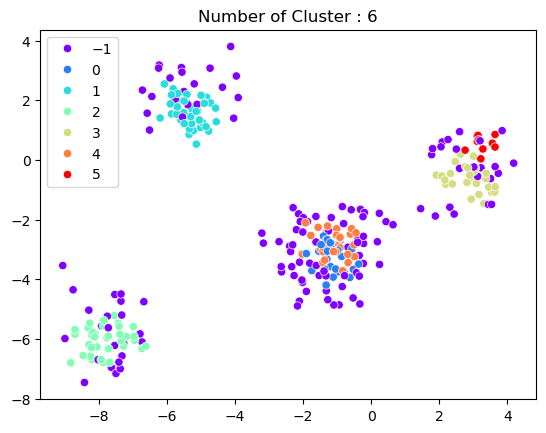

In [ ]:

import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import DBSCAN 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score,adjusted_rand_score
from sklearn.datasets import make_blobs 
import plotly.express as px 

X,y = make_blobs(n_samples=300,centers=5,n_features=3,cluster_std=0.70)

db_scan_model = DBSCAN(
    eps = 0.7,
    min_samples=10,
    metric= "euclidean",
)

db_scan_model.fit(X)
labels = db_scan_model.labels_ 
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

plt.title("Number of Cluster : %d"% n_clusters)
sns.scatterplot(
    x = X[:,0],
    y = X[:,1],
    hue = labels,
    markers= "o",
    palette='rainbow',
)
plt.show()

Principle Component Analysis

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("iris.csv")

Y = df["Species"]
X = df.drop(columns=["Id","Species"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
pca_x = pca.fit_transform(X_scaled)

model = LogisticRegression()
model.fit(pca_x,Y)
model.predict(pca_x)
print(model.score(pca_x,Y)) 


0.9333333333333333


Cross Validation and Hyper parameter training 

1. Cross Validation 

In [ ]:
from sklearn.model_selection import cross_val_score,cross_val_predict 
model = LogisticRegression()


scores = cross_val_score(
    estimator=model,
    X = X,
    y = Y,
    scoring= "accuracy",
    cv = 3,
)

preds = cross_val_predict(
    model,
    X,
    Y,
    cv = 3, 
)


(150,)


Mini Project : Model Optimizer 

In [74]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV 

grid_param = {
    "n_estimators" : [25,50,100],
    "max_depth" : [1,2,3,4,5,None],
    "min_samples_split" : [2,3,4],
    "min_samples_leaf" : [1,2,3,4], 
}

model = RandomForestClassifier()

Gridcv = GridSearchCV(
    estimator = model,
    param_grid= grid_param,
    scoring = "accuracy",
    cv = 3,
)

Randomcv = RandomizedSearchCV(
    estimator = model,
    param_distributions= grid_param,
    scoring = "accuracy",
    cv = 3 ,
)

Gridcv.fit(X,Y)
Randomcv.fit(X,Y)
print("Grid Search Results : ")
print(f"Best Score : {Gridcv.best_score_} \nBest Parameters : {Gridcv.best_params_}")
print("Random Search Results : ")
print(f"Best Score : {Randomcv.best_score_} \nBest Parameters : {Randomcv.best_params_}")


Grid Search Results : 
Best Score : 0.9733333333333333 
Best Parameters : {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Random Search Results : 
Best Score : 0.9733333333333333 
Best Parameters : {'n_estimators': 50, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': None}


Feature Engineering 

1. Univariate and multi variate Feature Engineering 

In [84]:
from sklearn.impute import SimpleImputer, KNNImputer 

marks = {
    "Name" : ["abc","efg","hij","klm","nop","qrst"],
    "Number" : [101,102,103,104,105,106],
    "marks" : [45,66,np.nan,np.nan,76,23],
    "age" : [18,18,18,np.nan,19,np.nan],
}
df = pd.DataFrame(marks)

imputer = SimpleImputer(missing_values=np.nan,strategy="mean")
imputer.fit(df[["Number","marks","age"]])
df[["Number","marks","age"]] = imputer.transform(df[["Number","marks","age"]])
df

,Name,Number,marks,age
0,abc,101.0,45.0,18.00
1,efg,102.0,66.0,18.00
2,hij,103.0,52.5,18.00
3,klm,104.0,52.5,18.25
4,nop,105.0,76.0,19.00
5,qrst,106.0,23.0,18.25


In [91]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df2 = pd.DataFrame(marks)
df3 = pd.DataFrame(marks)

imputer2 = KNNImputer(n_neighbors=2,weights="uniform")
imputer2.fit(df2[["Number","marks","age"]])
imputer3 = IterativeImputer(random_state=0)
imputer3.fit(df3[["Number","marks","age"]])

df2[["Number","marks","age"]] = imputer2.transform(df2[["Number","marks","age"]])
df3[["Number","marks","age"]] = imputer3.transform(df3[["Number","marks","age"]])

print("Dataframe Imputed using Simple Imputer : ")
print(df)
print("Dataframe Imputed using KNN Imputer : ")
print(df2)
print("DataFrame Imputed using Iterative Imputer : ")
print(df3)

Dataframe Imputed using Simple Imputer : 
   Name  Number  marks    age
0   abc   101.0   45.0  18.00
1   efg   102.0   66.0  18.00
2   hij   103.0   52.5  18.00
3   klm   104.0   52.5  18.25
4   nop   105.0   76.0  19.00
5  qrst   106.0   23.0  18.25
Dataframe Imputed using KNN Imputer : 
   Name  Number  marks   age
0   abc   101.0   45.0  18.0
1   efg   102.0   66.0  18.0
2   hij   103.0   55.5  18.0
3   klm   104.0   71.0  18.5
4   nop   105.0   76.0  19.0
5  qrst   106.0   23.0  18.0
DataFrame Imputed using Iterative Imputer : 
   Name  Number      marks        age
0   abc   101.0  45.000000  18.000000
1   efg   102.0  66.000000  18.000000
2   hij   103.0  52.500325  18.000000
3   klm   104.0  52.499563  18.097372
4   nop   105.0  76.000000  19.000000
5  qrst   106.0  23.000000  17.467402


Mini-Project : Smart Fill

In [124]:
from sklearn.metrics import accuracy_score 
df = pd.read_csv("d://AppstoneLab-AI-intern//Day-wise//Day-2//Titanic-Dataset.csv")
df = df.select_dtypes(include = ["int64","float64"])

y = df["Survived"]
X = df.drop(columns=["Survived"])

simple_imputer = SimpleImputer(missing_values=np.nan,strategy="mean")
knn_imputer = KNNImputer(missing_values=np.nan,weights="distance",n_neighbors=2)

simple_X = simple_imputer.fit_transform(X)
knn_X = knn_imputer.fit_transform(X)

model_1 = RandomForestClassifier(
    n_estimators=200,
    criterion = "gini",
    max_depth = 5,
)

x_train_simple,x_test_simple,y_train_simple,y_test_simple = train_test_split(simple_X,y)

x_train_knn,x_test_knn,y_train_knn,y_test_knn = train_test_split(knn_X,y)

model.fit(x_train_simple,y_train_simple)
simple_preds = model.predict(x_test_simple)

model.fit(x_train_knn,y_train_knn)
knn_preds = model.predict(x_test_knn)

print("Accuracy using simple imputer : ",accuracy_score(y_test_simple,simple_preds))
print("Accuracy using Kmeans imputer : ",accuracy_score(y_test_knn,knn_preds))


Accuracy using simple imputer :  0.7174887892376681
Accuracy using Kmeans imputer :  0.6771300448430493


Target Encoding

In [ ]:
df = pd.read_csv("d:\AppstoneLab-AI-intern\Day-wise\Day-4\CAR DETAILS FROM CAR DEKHO.csv")
df.info()
df["encoded_col"] = df.groupby("name")["selling_price"].transform("mean")
df["encoded_col"]

0       9.434783e+04
1       1.444167e+05
2       4.906664e+05
3       2.299999e+05
4       5.305556e+05
            ...     
4335    3.709998e+05
4336    4.099990e+05
4337    8.900000e+04
4338    1.186667e+06
4339    2.783333e+05
Name: encoded_col, Length: 4340, dtype: float64

In [155]:
import pandas as pd
data = pd.Series([0, 2, 5, 10, 25, 40, 50, 75, 90, 100])
bins = [0, 25, 50, 75, 100]
labels = ['young', 'adult', 'senior', 'Old']
data_binned_cut = pd.cut(data, bins=bins, labels=labels)

print(data_binned_cut.value_counts())



young     4
adult     2
Old       2
senior    1
Name: count, dtype: int64


Datetime feature Engineering 

In [19]:
import numpy as np
data = {
    "date" : pd.date_range(start='2025-10-19',periods=100),
    "activity" : np.random.poisson(lam=20,size=100),
}

date_df = pd.DataFrame(data)
date_df["rollingMean"] = date_df["activity"].rolling(window=5).mean()
print("Rolling mean : ")
print(date_df.head(10))

#extracting day of the week 
date_df["Weekend"] = date_df["date"].dt.day_of_week
print("adding Weekend days : ")
print(date_df.head(10))

date_df["Month"] = date_df["date"].dt.month 
print("Adding Month : ")
print(date_df.head(10))

Rolling mean : 
        date  activity  rollingMean
0 2025-10-19        24          NaN
1 2025-10-20        12          NaN
2 2025-10-21        13          NaN
3 2025-10-22        20          NaN
4 2025-10-23        23         18.4
5 2025-10-24        21         17.8
6 2025-10-25        23         20.0
7 2025-10-26        16         20.6
8 2025-10-27        29         22.4
9 2025-10-28        21         22.0
adding Weekend days : 
        date  activity  rollingMean  Weekend
0 2025-10-19        24          NaN        6
1 2025-10-20        12          NaN        0
2 2025-10-21        13          NaN        1
3 2025-10-22        20          NaN        2
4 2025-10-23        23         18.4        3
5 2025-10-24        21         17.8        4
6 2025-10-25        23         20.0        5
7 2025-10-26        16         20.6        6
8 2025-10-27        29         22.4        0
9 2025-10-28        21         22.0        1
Adding Month : 
        date  activity  rollingMean  Weekend  Month
0 

Variance Thresholding 

In [ ]:
from sklearn.feature_selection import VarianceThreshold 
X = np.array([
    [0, 2, 0, 3],
    [0, 1, 4, 3],
    [0, 1, 1, 3],
    [0, 1, 0, 3],
    [0, 1, 3, 3] ])

thresh = VarianceThreshold()

X_selected = thresh.fit_transform(X)
print("Orignal Shape : ",X.shape)
print("after applying Variance Thresholding : ",X_selected.shape)

Orignal Shape :  (5, 4)
after applying Variance Thresholding :  (5, 2)
[[2 0]
 [1 4]
 [1 1]
 [1 0]
 [1 3]]


Recursive Feature Elimination 

Mini-Project : The Selector

In [4]:
from sklearn.feature_selection import RFE 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = load_breast_cancer()
X = df.data
Y = df.target


x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=45)
model = RandomForestClassifier(n_estimators=150,max_depth=6)

print("Printing all the Features",df.feature_names)
Recursive_tree_elimator = RFE(
    estimator = model,
    n_features_to_select=5,
)
model.fit(x_train,y_train)
Recursive_tree_elimator.fit(x_train,y_train)

preds = model.predict(x_test)
y_preds = Recursive_tree_elimator.predict(x_test)

print("Accuracy of the model Before using RFE : ",accuracy_score(y_test,preds))
print("Accuracy of the model after using RFE : ",accuracy_score(y_test,y_preds))
print("Most Important selected features : ",df.feature_names[Recursive_tree_elimator.support_])

Printing all the Features ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Accuracy of the model Before using RFE :  0.9736842105263158
Accuracy of the model after using RFE :  0.9473684210526315
Most Important selected features :  ['mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concave points']


Tree-Based Feature Selection

In [ ]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = DecisionTreeClassifier(
    max_depth=10,
    random_state=45
)

model.fit(x_train_scaled,y_train)
preds = model.predict(x_test_scaled)
feature_importance_ = model.feature_importances_

selected_features = df.feature_names[feature_importance_ > 0.05]
print(selected_features)

['worst texture' 'worst perimeter' 'worst concave points']


3. Dimensionality Reduction

1. LDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


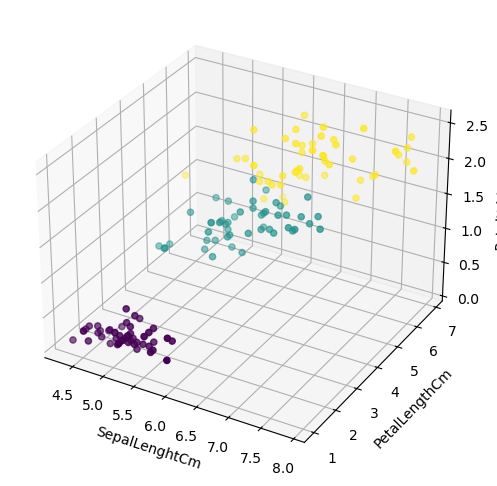

In [ ]:
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("d:\\AppstoneLab-AI-intern\\Day-wise\\Day-4\\Iris.csv")
y = df["Species"].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})
X = df.drop(columns=["Id","Species"])
df = df.drop(columns=["Id","Species"])
df.info()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X["SepalLengthCm"],X["PetalLengthCm"],X["PetalWidthCm"],c=y)
ax.set_xlabel("SepalLenghtCm")
ax.set_ylabel("PetalLengthCm")
ax.set_zlabel("PetalWidthCm")
plt.show()